# Thermodynamik – Spezifische Wärme und Schmelzwärme von Eis

In [2]:
import numpy as np 
from uncertainties import ufloat
from uncertainties import unumpy as unp
from IPython.display import Latex, HTML, Math, display
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress
import pandas as pd
from scipy import constants as c
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator


## Wärmekapazität und spezifische Wärme 

In diesem Experiment wird die spezifische Wärmekapazität von Wasser bestimmt, indem der zeitliche Temperaturanstieg bei konstanter elektrischer Heizleistung gemessen und durch einen linearen Fit ausgewertet wird.

### Durchführung und Versuchsaufbau

Ein Dewargefäß wird mit etwa 200 g Wasser gefüllt. Im Deckel sind, Heizwendel, Thermoelement und ein Rührer. Die Heizwendeln werden Spannungsrichtig in Serie geschaltet und mit U = 6V betrieben. Vor dem Einschalten der Heizung wird die Anfangstemperatur $T_0$ aufgenommen. Die Temperatur wird über das Thermoelement alle 30 s erfasst.  

Nach 2–3 Minuten Wartezeit wird die Heizung eingeschaltet und die Leistung $P_{el}$ zu dem Zeitpunkt Ermittelt. Nach etwa 10 Minuten wird die Heizung ausgemacht und die Temperatur kurz weiter aufgezeichnet.

Aus der linearen Beziehung

$$
\Delta Q = C_\mathrm{ges}\, \Delta T = P_\mathrm{el}\, \Delta t
$$

ergibt sich für dauraufhin die Steigung des Temperaturanstiegs

$$
b = \frac{P_\mathrm{el}}{C_k + C_w}.
$$

Mit der bekannten Wärmekapazität des Kalorimeters $C_k = (135 \pm 10)\,\mathrm{J/K}$ folgt für die Wärmekapazität des Wassers

$$
C_w = \frac{U I}{b} - C_k,
$$

und damit für die spezifische Wärme

$$
c_w = \frac{C_w}{m_w}.
$$

### Verwendete Geräte und Unsicherheiten

**???Spannungsquelle TTi EL-155R:???**
- Spannung: Auflösung 10 mV, Unsicherheit (0,3 % + 3 Digit)  
- Strom: Auflösung 1 mA, Unsicherheit (0,5 % + 3 Digit)

**Digitalmultimetermeter UNI-T UT61B:**
- Messbereich 0°C - 100°C 
- Auflösung 1 °C  
- Unsicherheit (1.2% + 3 Digits)

### Systematische Unsicherheiten

Die systematischen Unsicherheiten entstehen durch Wärmeverluste an die Umgebung, die trotz Dewargefäß nicht vollständig verhindert werden können. Zusätzlich führt die Annahme einer konstanten Heizleistung zu Abweichungen, da Transformator und Leitungen geringe Verluste aufweisen. Das Rührverhalten beeinflusst die Homogenität der Temperatur im Wasser, und die Reaktionszeit des Thermoelements sowie mögliche Kalibrierfehler tragen zur Unsicherheit bei.

### Ergebnisse:


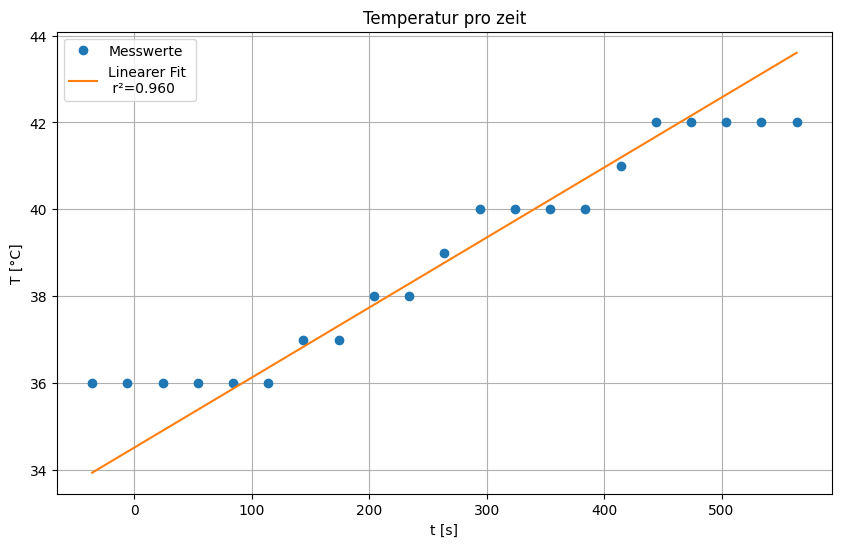

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [ ]:

# x = np.arange(0,600,30)
# y = np.random.normal(x/30,0.6)




T0 = 36

df = pd.read_csv("lol 2.csv", sep=',', decimal='.', engine='python')
y = df["T"].to_numpy()
x = df["t"].to_numpy() - T0

md = 236.5 # g
mwd = 408 # g #408


Ck = ufloat(135,10)
mw = ufloat(mwd-md,0.1)*1e-3

U1 = ufloat(6.24, 0.03)          #V
I1 = ufloat(2.68, 0.02)         #A

U2 = ufloat(6.23, 0.03)
I2 = ufloat(2.67, 0.02)

P = (U1+U2)*(I1+I2)/2

res = linregress(x[4:-4],y[4:-4])
y1 = res.slope*x+res.intercept

n = "\n"

plt.figure(figsize=(10,6))
plt.plot(x,y,"o",label="Messwerte")
plt.plot(x,y1, "-", label=rf"Linearer Fit {n} r²={res.rvalue**2:.3f}")
plt.xlabel("t [s]")
plt.ylabel("T [°C]")
plt.title("Temperatur pro zeit")
plt.grid()
plt.legend()
plt.show()

Cw = P/res.slope - Ck
cw = Cw/mw


display(Latex(rf"$$P = {P:.2f}\mathrm{{\frac{{J}}{{s}}}}$$"))
display(Latex(rf"$$c_w = {cw:.2f}\mathrm{{\frac{{J}}{{K\cdot Kg}}}}$$"))

## Diskussion

## Schmelzwärme von Eis

 In diesem Experiment wird die spezifische Schmelzwärme von Eis bestimmt, indem Eis bei 0 °C in warmes Wasser gegeben wird und die resultierende Mischungstemperatur ausgewertet wird.


### Durchführung und Versuchsaufbau

Ein Dewargefäß wird mit ca. 70 °C heißem Wasser gefüllt und dessen Masse $m_w$ bestimmt. Ein würfel Eis wird auf ca. $0^\circ\mathrm{C}$ erwärmt und getrocknet und die Masse $m_e$ bestimmt. Vor dem Einwerfen wird die Wassertemperatur mehrere Minuten lang mit einem UT61B-Multimeter gemessen. Die Temperatur wird während und nach dem Schmelzvorgang einige Minuten weiter gemessen. Abschnitt I und III der Temperatur-Zeit Kurve werden mittels Linearem Fit Extrapoliert und daraus wird mittels Integration der Schnittpunkt S der Senkrechten bestimmt und daraus die Schnittüunkte $T_1$ und $t_M$

Die abgegebene Wärme des Kalorimeters und des Wassers lautet daraufhin:

$$
\Delta Q_1 = (C_k + m_w c_w)(T_1 - T_m),
$$

und die aufgenommene Wärme durch das Eis:

$$
\Delta Q_2 = m_e S + m_e c_w (T_m - T_S),
$$

wobei $T_S = 0^\circ\mathrm{C}$ die Schmelztemperatur des Eises (ca. 0°C) ist.  
Durch Gleichsetzen von $\Delta Q_1 = \Delta Q_2$ ergibt sich die spezifische Schmelzwärme:

$$
S = \frac{(C_k + m_w c_w)(T_1 - T_m)}{m_e} - c_w (T_m - T_S).
$$

### Verwendete Geräte und Unsicherheiten

**Digitalmultimetermeter UNI-T UT61B:**
- Messbereich 0°C - 100°C 
- Auflösung 1 °C  
- Unsicherheit (1.2% + 3 Digits)

**Waage:**  


### Systematische Unsicherheiten

Die Annahme, dass das Eis exakt bei $0^\circ\mathrm{C}$ liegt ist eine Näherung, die zu Abweichungen im berechneten $S$ führt.


### Ergebnisse:

[166.87682  167.134384 167.377092 167.6347   167.877445 168.135088
 168.377945 168.635409 168.878216 169.135734 169.378711 169.636012
 169.879041 170.136309 170.379511 170.63661  170.87995  171.13691
 171.380426 171.63712  171.880854 172.137554 172.381164 172.637936
 172.881469 173.138381 173.381801 173.638716 173.882072 174.139128
 174.382549 174.639522 174.882864 175.139794 175.383304 175.64021
 175.883618 176.140518 176.383929 176.640921 176.884135 177.141153
 177.384573 177.641467 177.884912 178.141792 178.385367 178.642085
 178.885829 179.142314 179.386079 179.642616 179.886407 180.142927
 180.38688  180.643135 180.887318 181.143418 181.387714 181.643701
 181.888109 182.143929 182.388567 182.644142 182.889026 183.144427
 183.389466 183.644751 183.889918 184.145233 184.390357 184.645679
 184.890703 185.146005 185.391156 185.646441 185.891605 186.146887
 186.392026 186.64716  186.892252 187.147578 187.39255  187.647969
 187.89281  188.14837  188.393022 188.648695 188.893427 189.1490

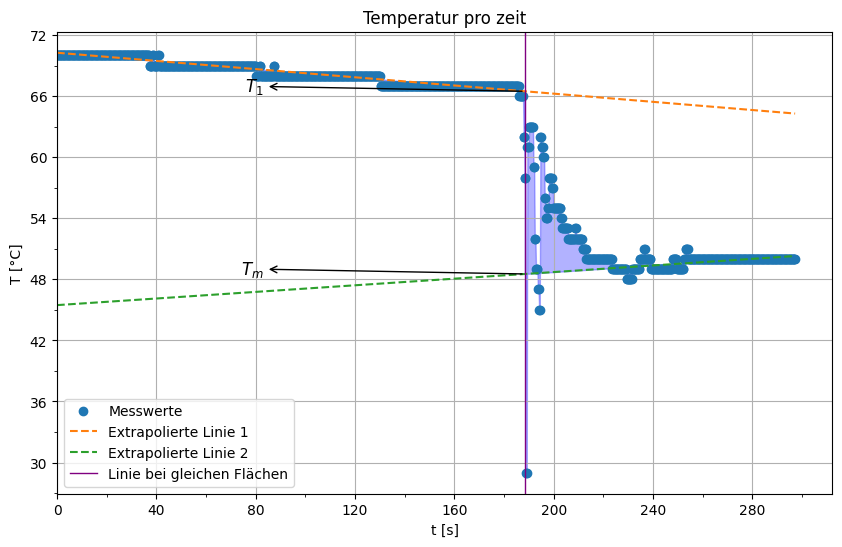

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [ ]:


df = pd.read_csv("haha2.csv", sep=',', decimal='.', engine='python')
y = df["T"].to_numpy()
x = df["t"].to_numpy()   

md = 236.5

Ck = ufloat(100,10)
cw = 4.19
me = ufloat(19.2,0.1)
mw = ufloat(399.7-md,0.1)


a = np.argmax(x)
res1 = linregress(x[:a//4],y[:a//4])

res2 = linregress(x[(a*3)//4:],y[(a*3)//4:])

# um den bereich für den abfall abzuschätzen:
y1 = res1.slope * x + res1.intercept
y2 = res2.slope * x + res2.intercept

d1 = np.abs(y - y1)
d2 = np.abs(y - y2)

g1 = np.where(d1 <= 0.1)[0][-1]
g2 = np.where(d2 <= 0.1)[0][0]


y0 = np.mean(y[g1:g2])

idx = np.argmin(np.abs(y - y0))
x0 = x[idx]

T1 = y1[idx]
Tm = y2[idx]


plt.figure(figsize=(10,6))
plt.plot(x,y,'o', label="Messwerte")
plt.plot(x,x*res1.slope+res1.intercept, "--", label="Extrapolierte Linie 1")
plt.plot(x,x*res2.slope+res2.intercept, "--", label="Extrapolierte Linie 2")
plt.annotate("$T_1$", (x0,y1[idx]),textcoords="offset points",xytext=(-x0, 0), ha='right', fontsize=12, arrowprops=dict(arrowstyle="<-"))
plt.annotate("$T_m$", (x0,y2[idx]),textcoords="offset points",xytext=(-x0, 0), ha='right', fontsize=12, arrowprops=dict(arrowstyle="<-"))
plt.axvline(x0, color="purple", linestyle="-", linewidth=1, label=r"Linie bei gleichen Flächen")
plt.fill_between(x, y, y1, where=(x <= x0),alpha=0.3, color="blue")
plt.fill_between(x, y, y2, where=(x0 <= x),alpha=0.3, color="blue")
plt.xlim(left=0)
plt.xlabel("t [s]")
plt.ylabel("T [°C]")
plt.title("Temperatur pro zeit")
plt.legend()
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=10))
plt.gca().xaxis.set_minor_locator(MaxNLocator(nbins=20))
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=8))
plt.gca().yaxis.set_minor_locator(MaxNLocator(nbins=16))
plt.grid()
plt.show()


#S = \frac{(C_k + m_w c_w)(T_1 - T_m)}{m_e} - c_w (T_m - T_S)

T1 = ufloat(T1, T1*0.012+3)
Tm = ufloat(Tm, Tm*0.012+3)


S = (Ck+mw*cw)*(T1 - Tm)/(me) - cw*(Tm - 0)

display(Latex(fr"$$m_{{eis}} = ({me:.1f}) \mathrm{{g}}$$"))
display(Latex(fr"$$m_{{Wasser}} = ({mw:.1f}) \mathrm{{g}}$$"))
display(Latex(fr"$$T_1 = ({T1:.0f}) \mathrm{{°C}}$$"))
display(Latex(fr"$$T_m = ({Tm:.0f}) \mathrm{{°C}}$$"))

display(Latex(fr"$$S = ({S:.0f}) \mathrm{{\frac{{J}}{{g}}}}$$"))



## Diskussion